In [21]:
import pickle
with open("./test.pkl", "rb") as f:
    id_embs = pickle.load(f)  

In [22]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [24]:
import sys
sys.path.append("../../third_party/arc2face")

In [25]:
from arc2face import CLIPTextModelWrapper, project_face_embs

In [26]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)
import torch
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    '../../checkpoints/arc2face', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    '../../checkpoints/arc2face', subfolder="arc2face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 33.30it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [27]:
pipeline = pipeline.to("cuda")

In [ ]:
from insightface.app import FaceAnalysis
app = FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))
def compare_face_insight(img1, img2):
        image = np.array(img1.convert("RGB"))[:,:,::-1]
        faces = app.get(image)
        faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        image = np.array(img2.convert("RGB"))[:,:,::-1]
        faces = app.get(image)
        faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
        return cos_sim

In [63]:
idx = 196
id_emb = id_embs["student_embeddings"][0][idx:idx+1]
id_emb = (id_emb/torch.norm(id_emb, dim=1, keepdim=True)).to(torch.float16).cuda()
id_emb = project_face_embs(pipeline, id_emb)    # pass through the encoder

num_images = 1 
images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=2.5, num_images_per_prompt=1).images

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:01<00:00, 22.51it/s]


In [64]:
compare_face_insight(Image.open(id_embs["filenames"][0][idx].replace("./fracface", "./")).resize((256, 256)), images[0].resize((256, 256)))

0.5230485200881958

In [ ]:
hstack([Image.open(id_embs["filenames"][0][idx].replace("./fracface", "./")).resize((256, 256)), images[0].resize((256, 256))])

In [37]:
id_embs["filenames"][0][idx]

'./training-tpdne/img_256.png'

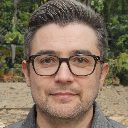

In [38]:
Image.open(id_embs["filenames"][0][120])